<a href="https://colab.research.google.com/github/FaridRash/Astroinformatics/blob/main/Notebooks/Farid_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Github**

In [ ]:
!git clone https://github.com/FaridRash/Astroinformatics

Cloning into 'Astroinformatics'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 15.44 MiB | 19.86 MiB/s, done.


In [ ]:
!unzip '/content/Astroinformatics/Data/Dataset.zip' -d '/content/Astroinformatics/Data/'

Streaming output truncated to the last 5000 lines.
  inflating: /content/Astroinformatics/Data/FRI/J000653.04-103510.5.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J000724.01-004516.7.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J000730.58-004815.7.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J001049.70-110812.9.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J001115.58-091619.7.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J001306.57+011404.3.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J001429.80-094555.3.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J001555.13-103557.9.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J001620.23-090710.6.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J001838.64-095157.2.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J002012.75+000450.4.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J002105.20+001500.9.jpg  
  inflating: /content/Astroinformatics/Data/FRI/J002137.47+01

#**Libraries**

In [ ]:
!pip install imutils

In [ ]:
!pip install plotly

In [ ]:
import cv2
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from imutils import paths
from tensorflow import keras
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow.nn import softmax
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


##GPU testing

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[]


#**Data**

##Fetching

In [ ]:
# Reading FR0 Images
imagePaths = list(paths.list_images(r"/content/Astroinformatics/Data/FR0"))

data = []
data_cropped = []
labels = []
label = 0
counter_0 = 0

for imagePath in imagePaths:
  image = tf.io.read_file(imagePath)
  image = tf.image.decode_image(image, channels=1)
  data.append(image)
  labels.append(label)
  counter_0 += 1
print(f'Loaded FR0... {counter_0} files has loaded.')

Loaded FR0... 6066 files has loaded.


In [ ]:
# Reading FRI Images
imagePaths = list(paths.list_images(r"/content/Astroinformatics/Data/FRI"))


label = 1
counter_1 = 0

for imagePath in imagePaths:
  image = tf.io.read_file(imagePath)
  image = tf.image.decode_image(image, channels=1)
  data.append(image)
  labels.append(label)
  counter_1 += 1
print(f'Loaded FRI... {counter_1} files has loaded.')

Loaded FRI... 5008 files has loaded.


In [ ]:
# Reading FRII Images
imagePaths = list(paths.list_images(r"/content/Astroinformatics/Data/FRII"))

label = 2
counter_2 = 0

for imagePath in imagePaths:
  image = tf.io.read_file(imagePath)
  image = tf.image.decode_image(image, channels=1)
  data.append(image)
  labels.append(label)
  counter_2 += 1
print(f'Loaded FRII... {counter_2} files has loaded.')

Loaded FRII... 2066 files has loaded.


##Cropping

In [ ]:
data_cropped = []
for image in data:
  image = tf.image.crop_to_bounding_box(image, 120, 120, 60, 60)
  data_cropped.append(image)

##Data Distribution

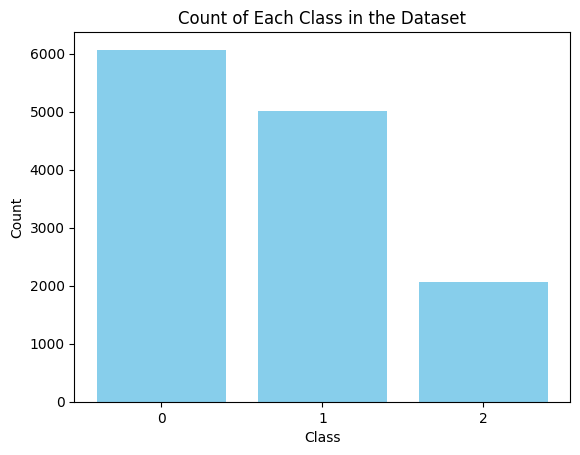

In [ ]:
counter = Counter(labels)
sorted_counts = dict(sorted(counter.items()))
plt.bar(sorted_counts.keys(), sorted_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Count of Each Class in the Dataset')
plt.xticks(range(3))
plt.show()

##Converting the lists to a NumPy array

In [ ]:
labels = np.array(labels,dtype='uint8')
data = np.array(data,dtype='uint8')
data_cropped = np.array(data_cropped,dtype='uint8')

#**EDA**

##Displaying sample images

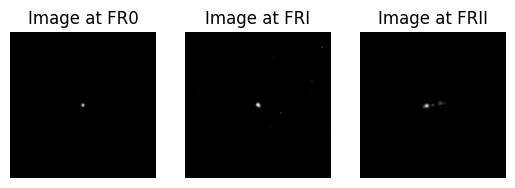

In [ ]:
class_0 = data[labels == 0]
image = np.squeeze(class_0[1])
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FR0")

class_1 = data[labels == 1]
image = np.squeeze(class_1[1])
plt.subplot(1, 3, 2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FRI")

class_2 = data[labels == 2]
image = np.squeeze(class_2[1])
plt.subplot(1, 3, 3)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FRII")


plt.show()

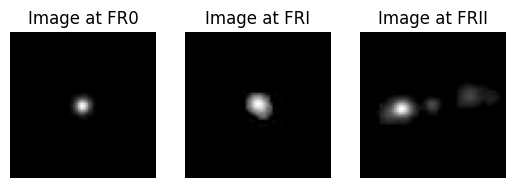

In [ ]:
class_0 = data_cropped[labels == 0]
image = np.squeeze(class_0[1])
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FR0")

class_1 = data_cropped[labels == 1]
image = np.squeeze(class_1[1])
plt.subplot(1, 3, 2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FRI")

class_2 = data_cropped[labels == 2]
image = np.squeeze(class_2[1])
plt.subplot(1, 3, 3)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FRII")


plt.show()

##Filterring

In [ ]:
data_cropped.shape, labels.shape

((13140, 60, 60, 1), (13140,))

In [ ]:
mask = np.array([np.max(image) >= 5 for image in data_cropped])
filtered_data = data_cropped[mask]
filtered_labels = labels[mask]

In [ ]:
mask_useless = np.array([np.max(image) < 5 for image in data_cropped])
useless_data = data_cropped[mask_useless]
useless_labels = labels[mask_useless]

In [ ]:
class_0_useless = useless_data[useless_labels == 0]
class_1_useless = useless_data[useless_labels == 1]
class_2_useless = useless_data[useless_labels == 2]

In [ ]:
np.max(class_0_useless), np.max(class_1_useless), np.max(class_2_useless)

(np.uint8(2), np.uint8(0), np.uint8(2))

In [ ]:
class_0_useless.shape, class_1_useless.shape, class_2_useless.shape

((94, 60, 60, 1), (40, 60, 60, 1), (36, 60, 60, 1))

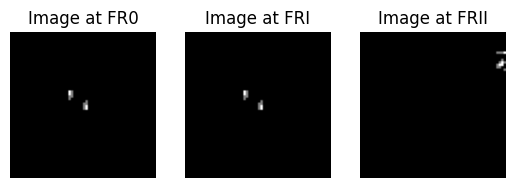

In [ ]:
temp = 0
for i in class_0_useless:
  if np.max(i) >temp:
    temp = np.max(i)
    image = np.squeeze(i)
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FR0")

temp = 0
for i in class_1_useless:
  if np.max(i) >temp:
    temp = np.max(i)
    image = np.squeeze(i)
plt.subplot(1, 3, 2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FRI")

temp = 0
for i in class_2_useless:
  if np.max(i) >temp:
    temp = np.max(i)
    image = np.squeeze(i)
plt.subplot(1, 3, 3)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Image at FRII")


plt.show()

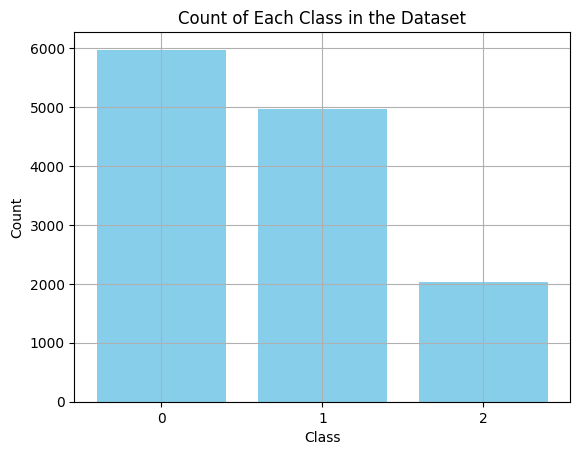

In [ ]:
counter = Counter(filtered_labels)
sorted_counts = dict(sorted(counter.items()))
plt.bar(sorted_counts.keys(), sorted_counts.values(), color='skyblue')
plt.grid(True)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Count of Each Class in the Dataset')
plt.xticks(range(3))
plt.show()

In [ ]:
class_0_image = filtered_data[filtered_labels == 0]
class_1_image = filtered_data[filtered_labels == 1]
class_2_image = filtered_data[filtered_labels == 2]
class_0_image.shape, class_1_image.shape, class_2_image.shape

((5972, 60, 60, 1), (4968, 60, 60, 1), (2030, 60, 60, 1))

##Flattening

In [ ]:
class_0_flatten = []
class_1_flatten = []
class_2_flatten = []


for image in final_data[final_labels == 0]:
    class_0_flatten.append(image.flatten())

for image in final_data[final_labels == 1]:
    class_1_flatten.append(image.flatten())

for image in final_data[final_labels == 2]:
    class_2_flatten.append(image.flatten())


class_0_flatten = np.array(class_0_flatten, dtype='uint8')
class_1_flatten = np.array(class_1_flatten, dtype='uint8')
class_2_flatten = np.array(class_2_flatten, dtype='uint8')

class_0_flatten.shape, class_1_flatten.shape, class_2_flatten.shape, final_data.shape, final_labels.shape

((5972, 3600), (5968, 3600), (6030, 3600), (17970, 60, 60, 1), (17970,))

##Displaing Flattened images

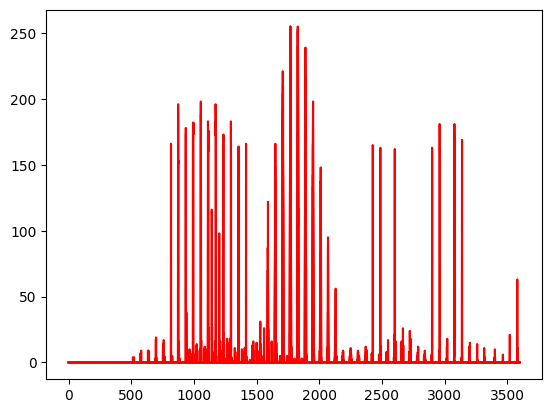

In [ ]:
for i in range(5):
    plt.plot(class_0_flatten[i], color='red')

plt.show();

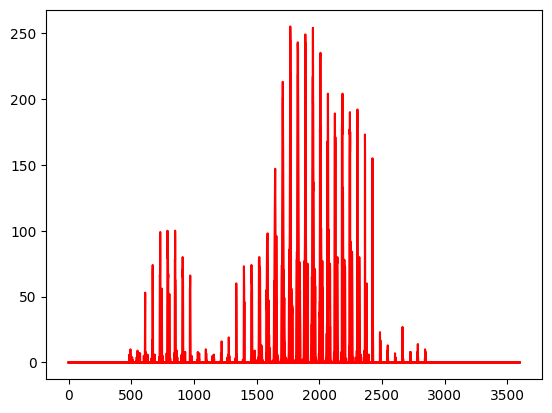

In [ ]:
for i in range(5):
    plt.plot(class_1_flatten[i], color='red')

plt.show();

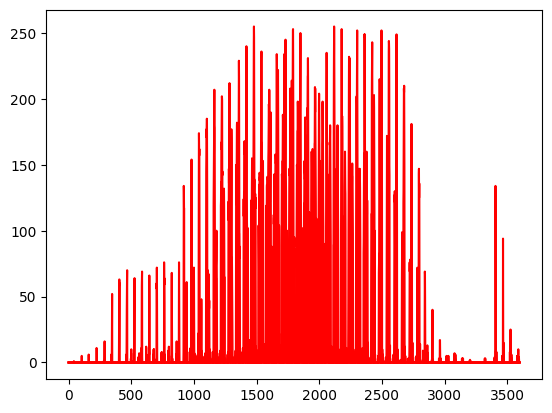

In [ ]:
for i in range(5):
    plt.plot(class_2_flatten[i], color='red')

plt.show();

##Pixels mean

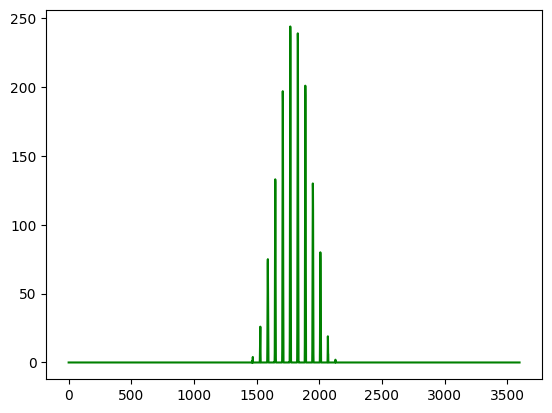

In [ ]:
class_0_median = np.median(class_0_flatten, axis=0)

plt.plot(class_0_median, color='green')
plt.show()

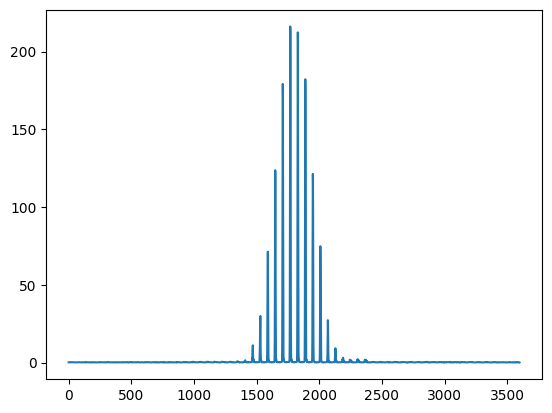

In [ ]:
class_0_mean = np.mean(class_0_flatten, axis=0)

plt.plot(class_0_mean)
plt.show()

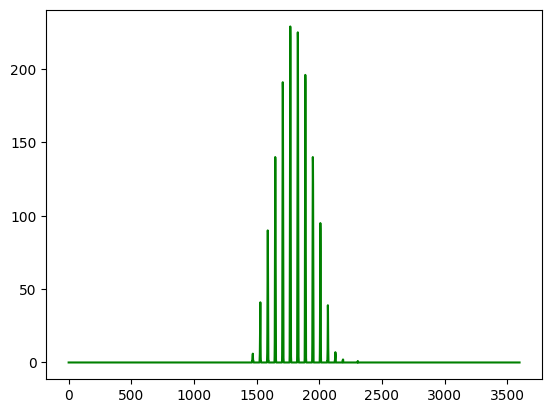

In [ ]:
class_1_median = np.median(class_1_flatten, axis=0)

plt.plot(class_1_median, color='green')
plt.show()

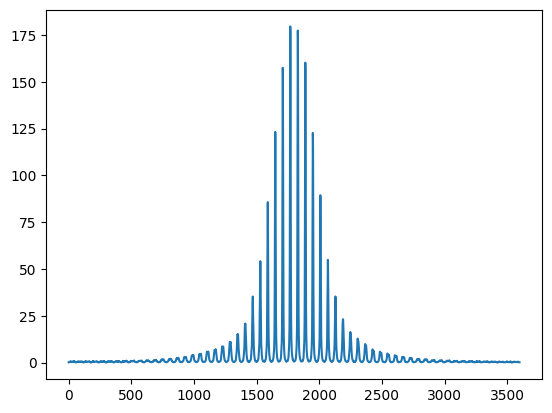

In [ ]:
class_1_mean = np.mean(class_1_flatten, axis=0)

plt.plot(class_1_mean)
plt.show()

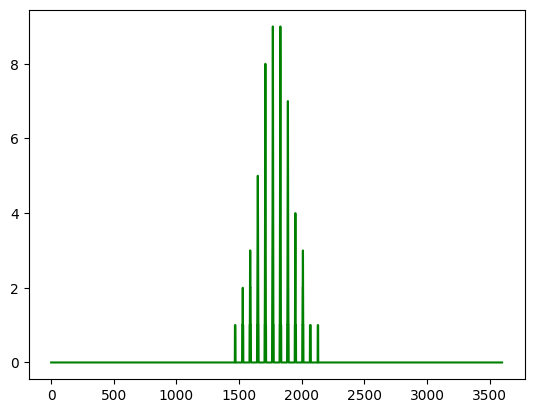

In [ ]:
class_2_median = np.median(class_2_flatten, axis=0)

plt.plot(class_2_median, color='green')
plt.show()

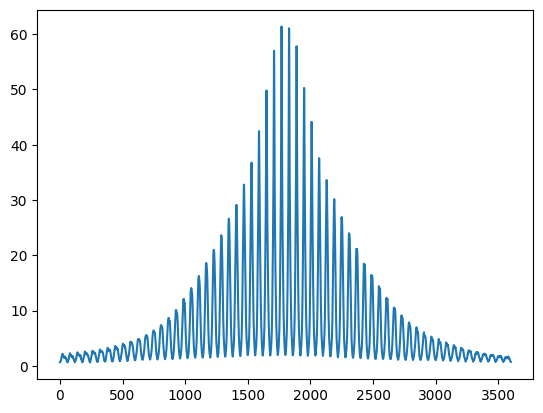

In [ ]:
class_2_mean = np.mean(class_2_flatten, axis=0)

plt.plot(class_2_mean)
plt.show()

##Pixels Correlation

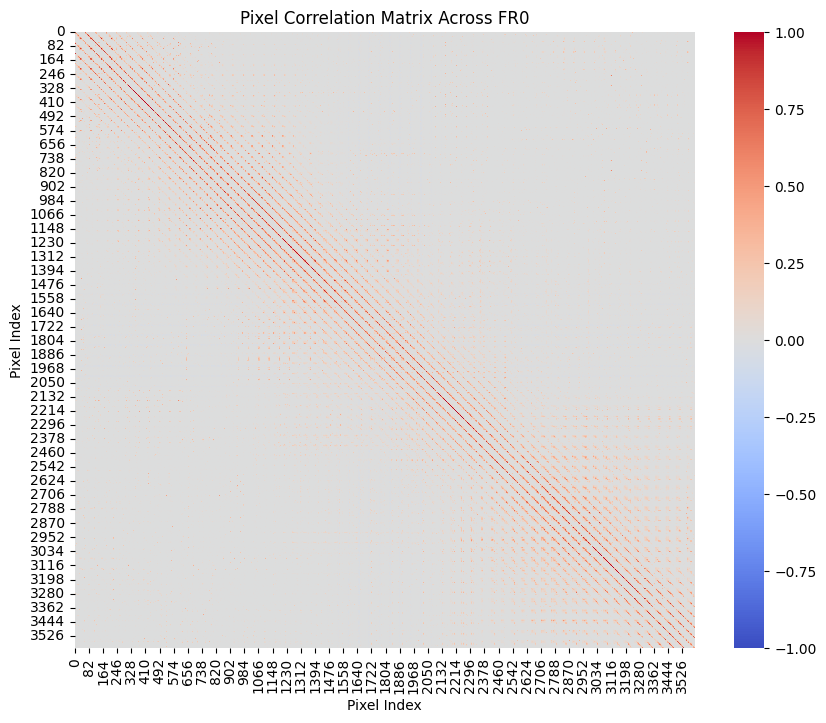

In [ ]:
correlation_matrix = np.corrcoef(class_0_flatten, rowvar=False)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pixel Correlation Matrix Across FR0")
plt.xlabel("Pixel Index")
plt.ylabel("Pixel Index")
plt.show()

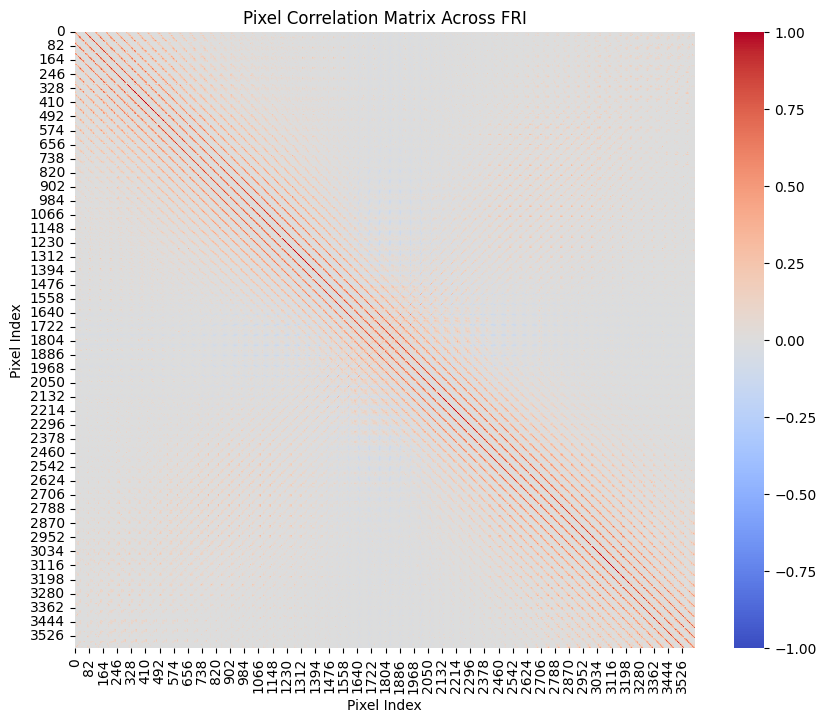

In [ ]:
correlation_matrix = np.corrcoef(class_1_flatten, rowvar=False)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pixel Correlation Matrix Across FRI")
plt.xlabel("Pixel Index")
plt.ylabel("Pixel Index")
plt.show()

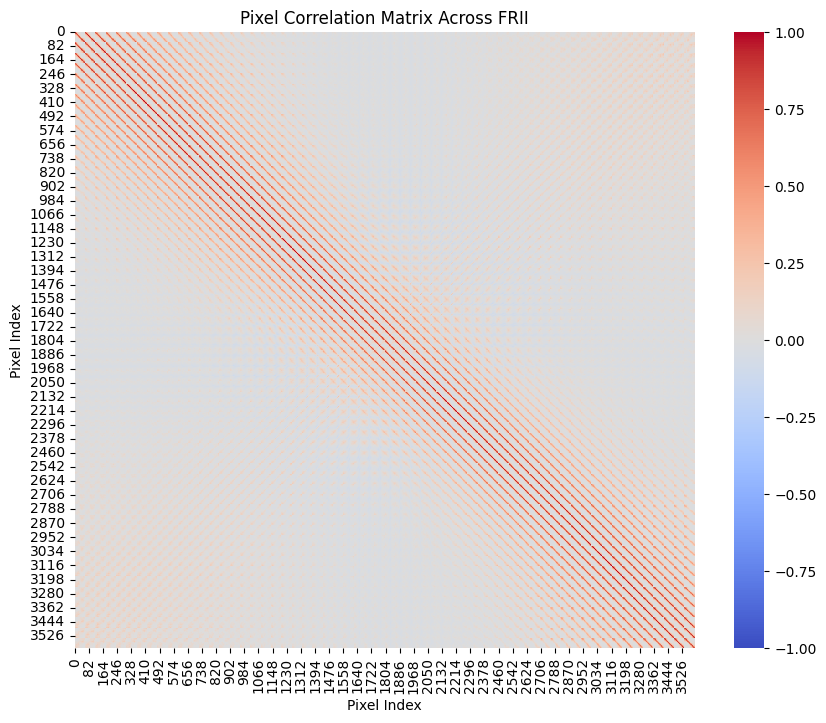

In [ ]:
correlation_matrix = np.corrcoef(class_2_flatten, rowvar=False)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pixel Correlation Matrix Across FRII")
plt.xlabel("Pixel Index")
plt.ylabel("Pixel Index")
plt.show()

##Sobel

In [ ]:
class_0_image = final_data[final_labels == 0]
class_1_image = final_data[final_labels == 1]
class_2_image = final_data[final_labels == 2]

In [ ]:
class_0_image.shape, class_1_image.shape, class_2_image.shape

((5972, 60, 60, 1), (5968, 60, 60, 1), (6030, 60, 60, 1))

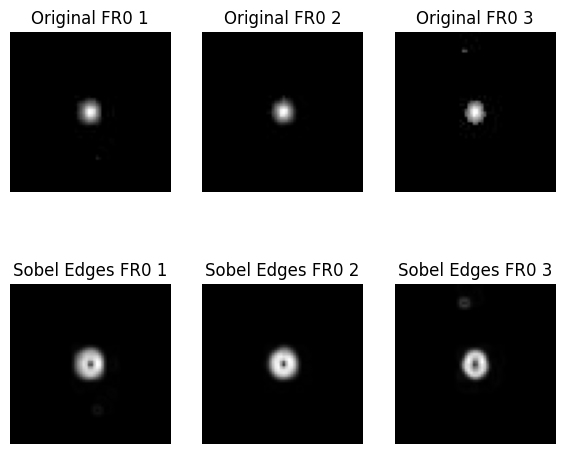

In [ ]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
edge_image = np.sqrt(sobel_x**2 + sobel_y**2)

plt.figure(figsize=(12, 6))
for i in range(3):
    image = class_0_image[i]
    sobel_x = cv2.Sobel(class_0_image[i], cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(class_0_image[i], cv2.CV_64F, 0, 1, ksize=5)
    edge_image = np.sqrt(sobel_x**2 + sobel_y**2)
    plt.subplot(2, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original FR0 {i+1}")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(edge_image, cmap='gray')
    plt.title(f"Sobel Edges FR0 {i+1}")
    plt.axis('off')

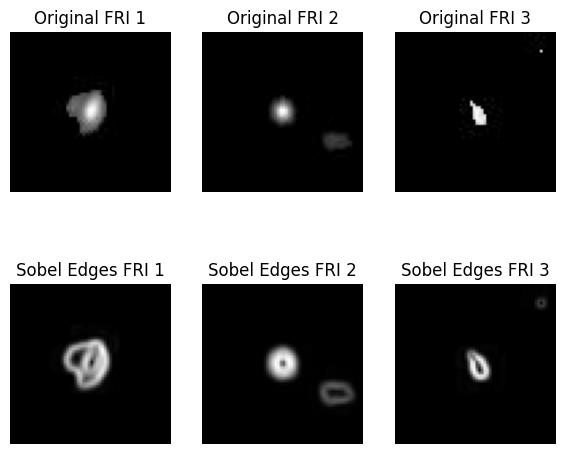

In [ ]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
edge_image = np.sqrt(sobel_x**2 + sobel_y**2)

plt.figure(figsize=(12, 6))
for i in range(3):
    image = class_1_image[i]
    sobel_x = cv2.Sobel(class_1_image[i], cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(class_1_image[i], cv2.CV_64F, 0, 1, ksize=5)
    edge_image = np.sqrt(sobel_x**2 + sobel_y**2)
    plt.subplot(2, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original FRI {i+1}")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(edge_image, cmap='gray')
    plt.title(f"Sobel Edges FRI {i+1}")
    plt.axis('off')

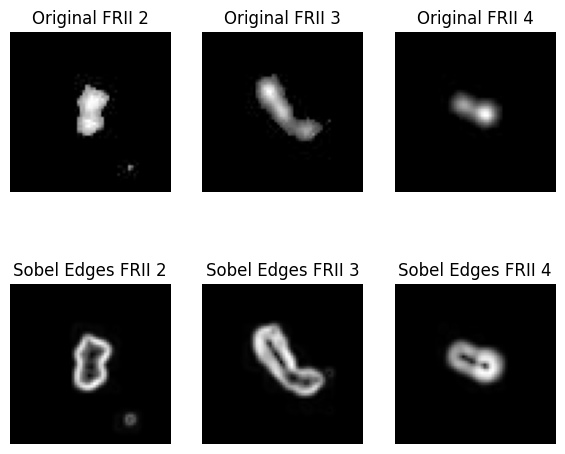

In [ ]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
edge_image = np.sqrt(sobel_x**2 + sobel_y**2)

plt.figure(figsize=(12, 6))
for i in range(1, 4):
    image = class_2_image[i]
    sobel_x = cv2.Sobel(class_2_image[i], cv2.CV_64F, 1, 0, ksize=5)
    sobel_y = cv2.Sobel(class_2_image[i], cv2.CV_64F, 0, 1, ksize=5)
    edge_image = np.sqrt(sobel_x**2 + sobel_y**2)
    plt.subplot(2, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original FRII {i+1}")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(edge_image, cmap='gray')
    plt.title(f"Sobel Edges FRII {i+1}")
    plt.axis('off')

##Symmetry

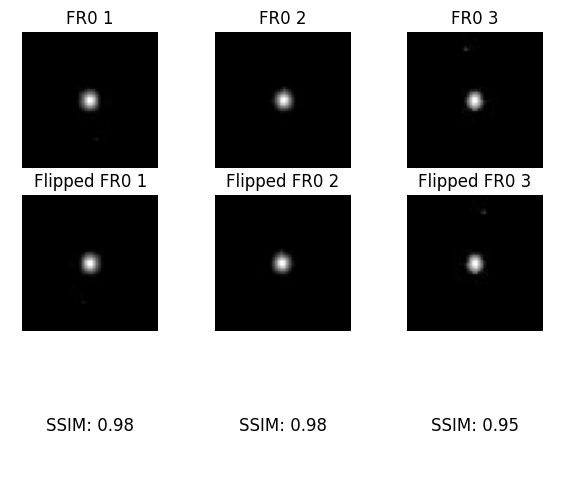

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(3):
    image = class_0_image[i]
    image = cv2.resize(image, (50, 50))

    flipped_image = cv2.flip(image, 1)

    symmetry_score, _ = ssim(image, flipped_image, full=True)


    # Original Image
    plt.subplot(3, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"FR0 {i+1}")
    plt.axis('off')

    # Flipped Image
    flipped_image = cv2.flip(image, 1)
    plt.subplot(3, 5, i+6)
    plt.imshow(flipped_image, cmap='gray')
    plt.title(f"Flipped FR0 {i+1}")
    plt.axis('off')

    # Symmetry Score
    plt.subplot(3, 5, i+11)
    plt.text(0.5, 0.5, f"SSIM: {symmetry_score:.2f}", ha='center', va='center', fontsize=12)
    plt.axis('off')

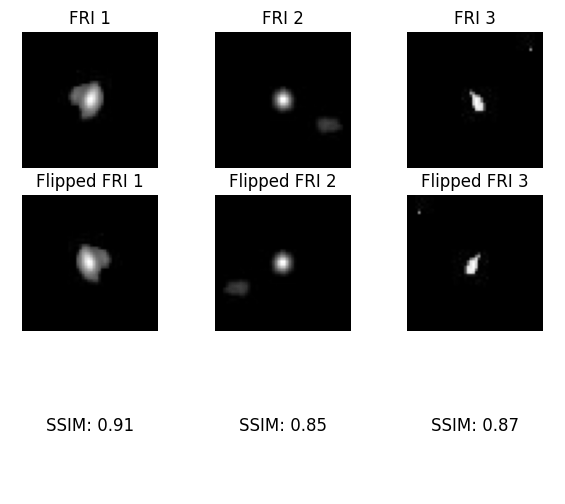

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(3):
    image = class_1_image[i]
    image = cv2.resize(image, (50, 50))

    flipped_image = cv2.flip(image, 1)

    symmetry_score, _ = ssim(image, flipped_image, full=True)


    # Original Image
    plt.subplot(3, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"FRI {i+1}")
    plt.axis('off')

    # Flipped Image
    flipped_image = cv2.flip(image, 1)
    plt.subplot(3, 5, i+6)
    plt.imshow(flipped_image, cmap='gray')
    plt.title(f"Flipped FRI {i+1}")
    plt.axis('off')

    # Symmetry Score
    plt.subplot(3, 5, i+11)
    plt.text(0.5, 0.5, f"SSIM: {symmetry_score:.2f}", ha='center', va='center', fontsize=12)
    plt.axis('off')

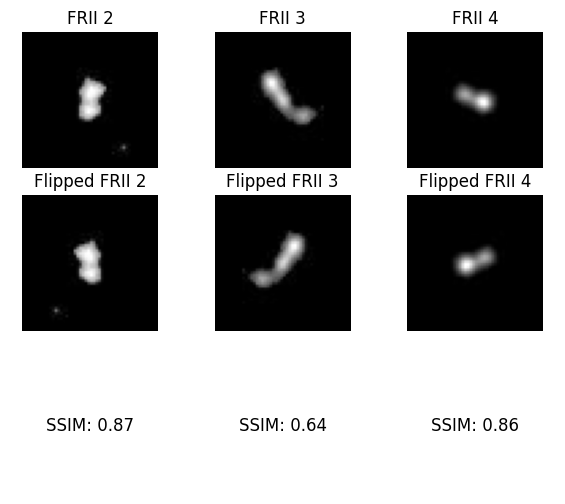

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(1, 4):
    image = class_2_image[i]
    image = cv2.resize(image, (50, 50))

    flipped_image = cv2.flip(image, 1)

    symmetry_score, _ = ssim(image, flipped_image, full=True)


    # Original Image
    plt.subplot(3, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"FRII {i+1}")
    plt.axis('off')

    # Flipped Image
    flipped_image = cv2.flip(image, 1)
    plt.subplot(3, 5, i+6)
    plt.imshow(flipped_image, cmap='gray')
    plt.title(f"Flipped FRII {i+1}")
    plt.axis('off')

    # Symmetry Score
    plt.subplot(3, 5, i+11)
    plt.text(0.5, 0.5, f"SSIM: {symmetry_score:.2f}", ha='center', va='center', fontsize=12)
    plt.axis('off')

In [ ]:
flipped_class_0_scores = []

for i in class_0_image:
    image = cv2.resize(i, (50, 50))
    flipped_image = cv2.flip(image, 1)
    symmetry_score, _ = ssim(image, flipped_image, full=True)
    flipped_class_0_scores.append(symmetry_score)

flipped_class_0_scores = np.array(flipped_class_0_scores)
flipped_class_0_scores_mean = np.mean(flipped_class_0_scores)
flipped_class_0_scores.shape

(5972,)

In [ ]:
flipped_class_1_scores = []

for i in class_1_image:
    image = cv2.resize(i, (50, 50))
    flipped_image = cv2.flip(image, 1)
    symmetry_score, _ = ssim(image, flipped_image, full=True)
    flipped_class_1_scores.append(symmetry_score)

flipped_class_1_scores = np.array(flipped_class_1_scores)
flipped_class_1_scores_mean = np.mean(flipped_class_1_scores)
flipped_class_1_scores.shape

(5968,)

In [ ]:
flipped_class_2_scores = []

for i in class_2_image:
    image = cv2.resize(i, (50, 50))
    flipped_image = cv2.flip(image, 1)
    symmetry_score, _ = ssim(image, flipped_image, full=True)
    flipped_class_2_scores.append(symmetry_score)

flipped_class_2_scores = np.array(flipped_class_2_scores)
flipped_class_2_scores_mean = np.mean(flipped_class_2_scores)
flipped_class_2_scores.shape

(6030,)

FR0 numbers: (5972,) , FRI Numbers: (5968,), FRII Numbers: (6030,)
FR0 Symmetry Score: 0.95 , FRI Symmetry Score: 0.82, FRII Symmetry Score: 0.70


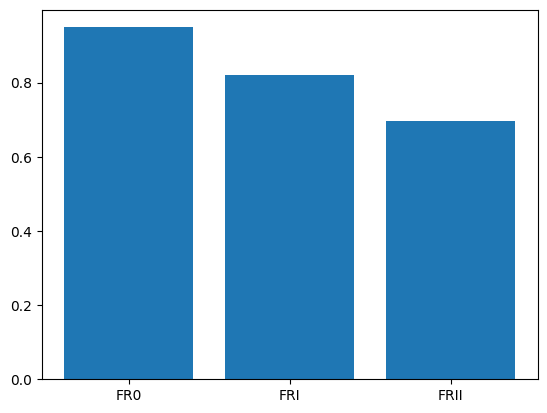

In [ ]:
print(f'FR0 numbers: {flipped_class_0_scores.shape} , FRI Numbers: {flipped_class_1_scores.shape}, FRII Numbers: {flipped_class_2_scores.shape}')
print(f'FR0 Symmetry Score: {flipped_class_0_scores_mean:0.2f} , FRI Symmetry Score: {flipped_class_1_scores_mean:0.2f}, FRII Symmetry Score: {flipped_class_2_scores_mean:0.2f}')


flipped_labels = ['FR0', 'FRI', 'FRII']
flipped_values = [flipped_class_0_scores_mean, flipped_class_1_scores_mean, flipped_class_2_scores_mean]
plt.bar(flipped_labels, flipped_values)
plt.show()


#**Normalization**

In [ ]:
np.min(final_data[0]), np.max(final_data[0])

(0, 248)

In [ ]:
data_normalized = final_data / 255

In [ ]:
print(f'Min of original = {np.min(final_data[0])}')
print(f'Max of original = {np.max(final_data[0])}')
print(f'Min of original = {np.min(data_normalized[0])}')
print(f'Max of original = {np.max(data_normalized[0])}')

Min of original = 0
Max of original = 248
Min of original = 0.0
Max of original = 0.9725490196078431


#**Splitting**

In [ ]:
x = data_normalized
y = final_labels
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((12579, 60, 60, 1), (12579,), (5391, 60, 60, 1), (5391,))

#**Augmentation**

In [ ]:
datagen = ImageDataGenerator(rotation_range=30,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             zoom_range=0.2,
                             shear_range=0.2,
                             horizontal_flip=True,
                             fill_mode='nearest')
class_2_data = filtered_data[filtered_labels == 2]
class_1_data = filtered_data[filtered_labels == 1]


augmented_class_2_data = []
augmented_class_2_labels = []

for i in range(4000):
    image = class_2_data[np.random.randint(0, len(class_2_data))]
    augmented_image = datagen.random_transform(image)
    augmented_class_2_data.append(augmented_image)
    augmented_class_2_labels.append(2)



augmented_class_1_data = []
augmented_class_1_labels = []

for i in range(1000):
    image = class_1_data[np.random.randint(0, len(class_1_data))]
    augmented_image = datagen.random_transform(image)
    augmented_class_1_data.append(augmented_image)
    augmented_class_1_labels.append(1)


In [ ]:
augmented_class_2_data = np.array(augmented_class_2_data)
augmented_class_2_labels = np.array(augmented_class_2_labels)

augmented_class_1_data = np.array(augmented_class_1_data)
augmented_class_1_labels = np.array(augmented_class_1_labels)

final_data = np.concatenate((filtered_data, augmented_class_2_data, augmented_class_1_data), axis=0)
final_labels = np.concatenate((filtered_labels, augmented_class_2_labels, augmented_class_1_labels), axis=0)

In [ ]:
print("Final data shape:", final_data.shape)
print("Final labels shape:", final_labels.shape)

Final data shape: (17970, 60, 60, 1)
Final labels shape: (17970,)


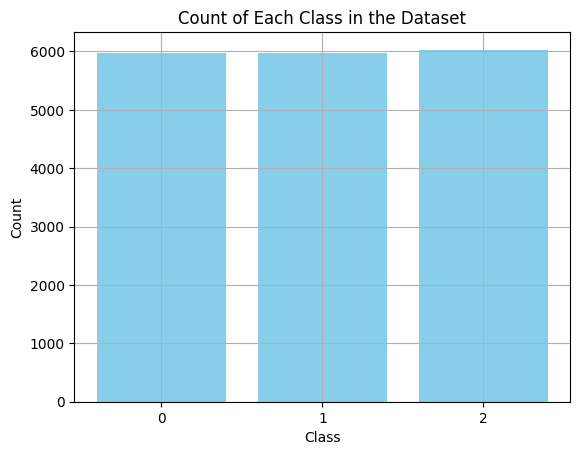

In [ ]:
counter = Counter(final_labels)
sorted_counts = dict(sorted(counter.items()))
plt.bar(sorted_counts.keys(), sorted_counts.values(), color='skyblue')
plt.grid(True)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Count of Each Class in the Dataset')
plt.xticks(range(3))
plt.show()

#**CNN**

##**CNN Architecture**

In [ ]:
model_cnn = keras.Sequential()

#Seed
tf.random.set_seed(42)

#CNN
model_cnn.add(keras.layers.Conv2D(8, kernel_size=(3,3), input_shape=(60, 60, 1)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.Activation('relu'))

model_cnn.add(keras.layers.Conv2D(16, kernel_size=(3,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.Activation('relu'))
model_cnn.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model_cnn.add(keras.layers.Conv2D(16, kernel_size=(3,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.Activation('relu'))

model_cnn.add(keras.layers.Conv2D(32, kernel_size=(3,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.Activation('relu'))
model_cnn.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model_cnn.add(keras.layers.Conv2D(64, kernel_size=(3,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.Activation('relu'))
model_cnn.add(keras.layers.MaxPool2D(pool_size=(2, 2)))

model_cnn.add(keras.layers.Conv2D(64, kernel_size=(3,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.Activation('relu'))

model_cnn.add(keras.layers.Conv2D(128, kernel_size=(3,3)))
model_cnn.add(keras.layers.BatchNormalization())
model_cnn.add(keras.layers.Activation('relu'))


#Dense
model_cnn.add(keras.layers.Flatten())
model_cnn.add(keras.layers.Dense(units=64, activation='relu'))
model_cnn.add(keras.layers.Dropout(0.5))



#Output
model_cnn.add(keras.layers.Dense(units=3, activation=keras.activations.softmax))


#Model Compiling
optimizer = keras.optimizers.Adam(learning_rate=0.000009)
loss = keras.losses.SparseCategoricalCrossentropy()
metric = [keras.metrics.CategoricalAccuracy()]

model_cnn.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


#Builing and Summury
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 58, 58, 8)         80        
                                                                 
 batch_normalization (BatchN  (None, 58, 58, 8)        32        
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 58, 58, 8)         0         
                                                                 
 conv2d_1 (Conv2D)           (None, 56, 56, 16)        1168      
                                                                 
 batch_normalization_1 (Batc  (None, 56, 56, 16)       64        
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 56, 56, 16)        0

##**Early Stopping**

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=37, restore_best_weights=True)

##**CNN Fitting**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.unique(labels)  # Replace `labels` with your true labels
class_weights = compute_class_weight('balanced', classes=classes, y=labels)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class Weights:", class_weight_dict)

Class Weights: {0: 0.722057368941642, 1: 0.8746006389776357, 2: 2.1200387221684416}


In [ ]:
class_weight_dict = {0: 1.0, 1: 2.5, 2: 1.5}  # Higher weight for class 1

In [ ]:
start = time.perf_counter()
hist = model_cnn.fit(x_train,
                     y_train,
                     batch_size=512,
                     epochs=200,
                     validation_data=(x_test, y_test),
                     callbacks=[early_stopping],
                     class_weight=class_weight_dict )
end = time.perf_counter()

Epoch 1/200
25/25 [==============================] - 12s 63ms/step - loss: 2.1462 - accuracy: 0.3812 - val_loss: 1.0995 - val_accuracy: 0.3398
Epoch 2/200
25/25 [==============================] - 1s 33ms/step - loss: 1.9324 - accuracy: 0.4752 - val_loss: 1.1030 - val_accuracy: 0.3398
Epoch 3/200
25/25 [==============================] - 1s 32ms/step - loss: 1.8253 - accuracy: 0.5358 - val_loss: 1.1085 - val_accuracy: 0.3398
Epoch 4/200
25/25 [==============================] - 1s 32ms/step - loss: 1.7066 - accuracy: 0.5728 - val_loss: 1.1142 - val_accuracy: 0.3398
Epoch 5/200
25/25 [==============================] - 1s 33ms/step - loss: 1.6402 - accuracy: 0.5931 - val_loss: 1.1193 - val_accuracy: 0.3398
Epoch 6/200
25/25 [==============================] - 1s 32ms/step - loss: 1.5846 - accuracy: 0.6160 - val_loss: 1.1219 - val_accuracy: 0.3398
Epoch 7/200
25/25 [==============================] - 1s 32ms/step - loss: 1.5312 - accuracy: 0.6235 - val_loss: 1.1250 - val_accuracy: 0.3398
Epoch

In [ ]:
(end - start)/ 60

2.907779718333404

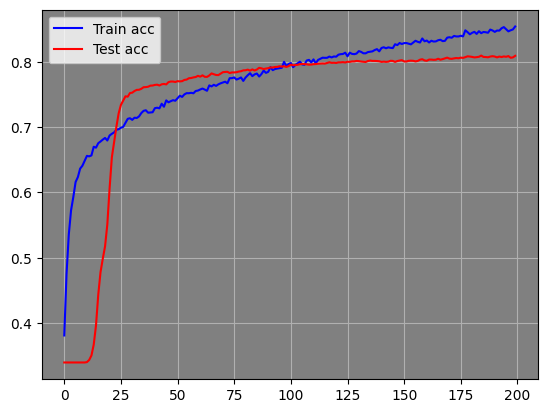

In [ ]:
acc_train = hist.history['accuracy']
acc_test = hist.history['val_accuracy']

plt.axes().set_facecolor('gray')
plt.grid('True')

plt.plot(acc_train, color='blue', label='Train acc')
plt.plot(acc_test, color='red', label='Test acc')

plt.legend()
plt.show()


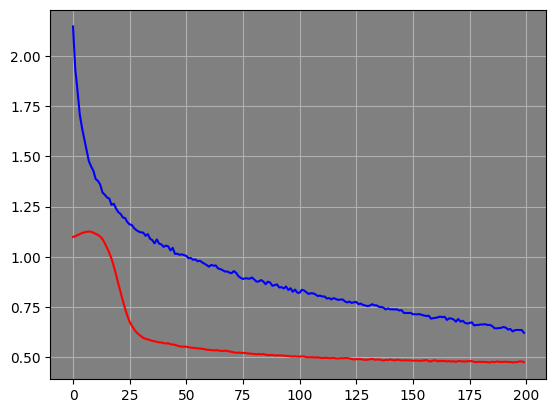

In [ ]:
loss_train = hist.history['loss']
loss_test = hist.history['val_loss']

plt.axes().set_facecolor('gray')
plt.grid('True')


plt.plot(loss_train, color='blue', label='Train loss');
plt.plot(loss_test, color='red', label='Test loss');


In [ ]:
model_cnn.evaluate(x=x_test, y=y_test)
model_cnn.evaluate(x=x_train, y=y_train)

394/394 [==============================] - 2s 4ms/step - loss: 0.3334 - accuracy: 0.8808


[0.3333624005317688, 0.8807536363601685]

In [ ]:
y_pred_train = model_cnn.predict(x_train)
y_pred_test = model_cnn.predict(x_test)


index_train = random.randint(0, 12579)
print(f'y_train: {y_train[index_train]} y_pred_train:{y_pred_train[index_train]}')

index_test = random.randint(0, 5391)
print(f'y_test: {y_test[index_test]} y_pred_test:{y_pred_test[index_test]}')

169/169 [==============================] - 1s 3ms/step
y_train: 0 y_pred_train:[0.8013  0.1696  0.02907]
y_test: 0 y_pred_test:[0.9185   0.07513  0.006355]


In [ ]:
y_pred_train_smax = softmax(y_pred_train, axis=1)
y_pred_test_smax = softmax(y_pred_test, axis=1)

y_pred_train_smax = np.argmax(y_pred_train_smax, axis=1)
y_pred_test_smax = np.argmax(y_pred_test_smax, axis=1)


y_pred_test_smax.shape, y_pred_train_smax.shape

((5391,), (12579,))

In [ ]:
acc_train = accuracy_score(y_train, y_pred_train_smax)
acc_test = accuracy_score(y_test, y_pred_test_smax)

p = precision_score(y_test, y_pred_test_smax, average='micro')
r = recall_score(y_test, y_pred_test_smax, average='micro')
f1 = f1_score(y_test, y_pred_test_smax, average='micro')


print(f'Acc Train: {acc_train} - Acc Test: {acc_test} - Percision: {p} - Recall: {r} - F1:{f1}')

Acc Train: 0.8807536370140711 - Acc Test: 0.8091263216471898 - Percision: 0.8091263216471898 - Recall: 0.8091263216471898 - F1:0.8091263216471898


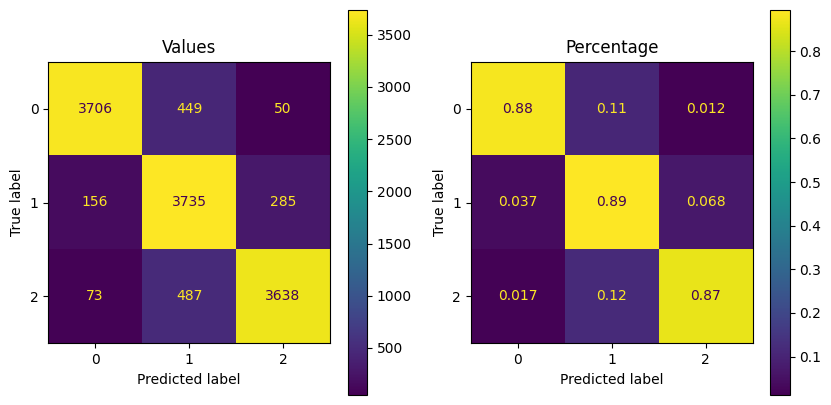

In [ ]:
cm_train = confusion_matrix(y_true=y_train, y_pred=y_pred_train_smax)
disp_cm_train = ConfusionMatrixDisplay(cm_train)

cm_train = cm_train.astype('float') / cm_train.sum(axis=1)[:, np.newaxis]
disp_cm_train_perce = ConfusionMatrixDisplay(cm_train)


fig , (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title('Values')
ax2.set_title('Percentage')
disp_cm_train.plot(ax=ax1);
disp_cm_train_perce.plot(ax=ax2);

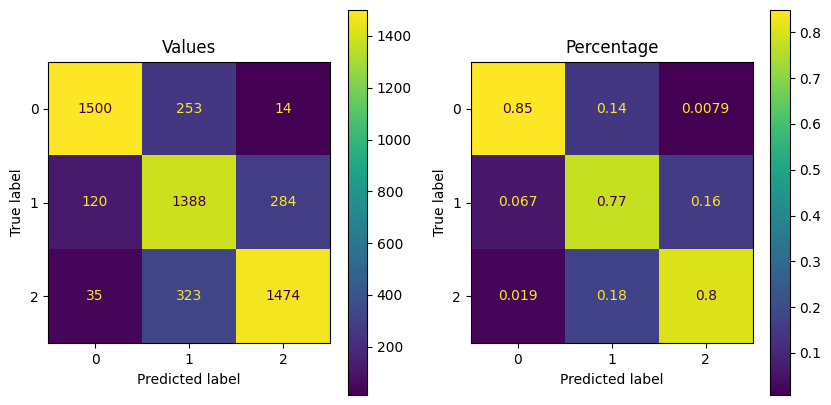

In [ ]:
cm_test = confusion_matrix(y_true=y_test, y_pred=y_pred_test_smax)
disp_cm_test = ConfusionMatrixDisplay(cm_test)

cm_test = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
disp_cm_test_perce = ConfusionMatrixDisplay(cm_test)


fig , (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title('Values')
ax2.set_title('Percentage')
disp_cm_test.plot(ax=ax1);
disp_cm_test_perce.plot(ax=ax2);